In [1]:
# CELL 1: IMPORTS

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import joblib
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

os.makedirs('../results', exist_ok=True)
os.makedirs('../data', exist_ok=True)

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

print(' Libraries imported!')
print('Libraries: numpy, pandas, sklearn, imbalanced-learn')

 Libraries imported!
Libraries: numpy, pandas, sklearn, imbalanced-learn


In [2]:
#CELL 2: LOAD DATA

try:
    df = pd.read_csv('C:/Users/yajne/Desktop/CREDIT_CARD_FREAUD/data/creditcard.csv')
    print(' Full dataset loaded!')
except FileNotFoundError:
    df = pd.read_csv('../data/sample_creditcard.csv')
    print('  Sample dataset loaded.')

print(f'Shape: {df.shape}')
print(f'Fraud rate: {df["Class"].mean()*100:.4f}%')
print(f'\nClass counts:')
print(df['Class'].value_counts())

 Full dataset loaded!
Shape: (284807, 31)
Fraud rate: 0.1727%

Class counts:
Class
0    284315
1       492
Name: count, dtype: int64


=== Step 1: Feature Engineering ===
  Original features: 30 (Time + V1-V28 + Amount)
  After engineering: 32 input features
  Added: Hour_sin, Hour_cos, Log_Amount
  Removed: Time (replaced by cyclical encoding)


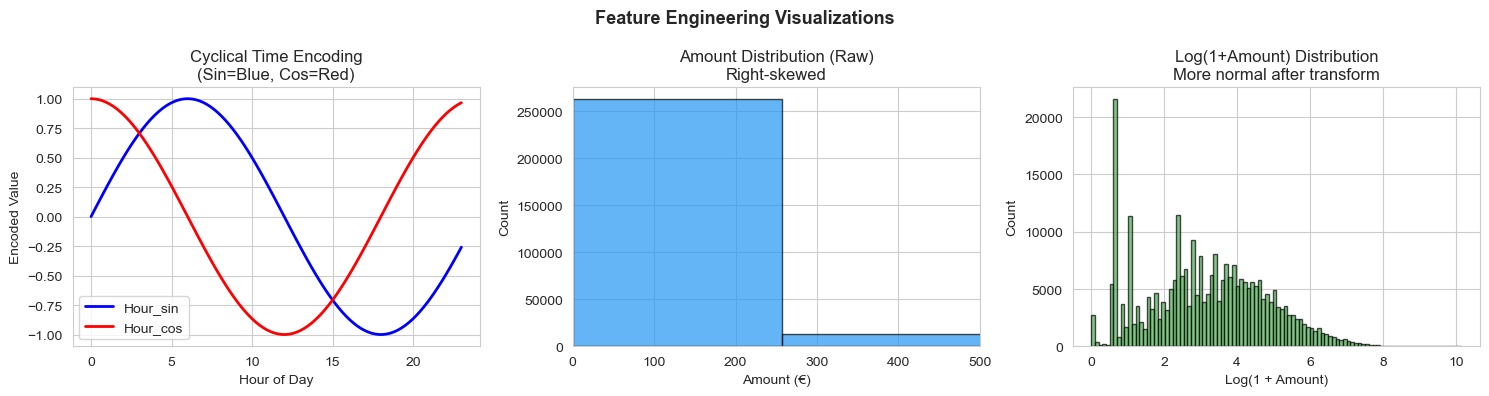


 Saved: results/feature_engineering.png


In [3]:
# CELL 3: FEATURE ENGINEERING

print('=== Step 1: Feature Engineering ===')
df_fe = df.copy()

# 1. TIME: Convert to hour of day using cyclical encoding
# Cyclical encoding preserves the circular nature of time
# (hour 23 is close to hour 0)
df_fe['Hour'] = (df_fe['Time'] / 3600) % 24
df_fe['Hour_sin'] = np.sin(2 * np.pi * df_fe['Hour'] / 24)
df_fe['Hour_cos'] = np.cos(2 * np.pi * df_fe['Hour'] / 24)

# 2. AMOUNT: Log-transform to reduce right skewness
# log1p(x) = log(1+x) handles Amount=0 cases
df_fe['Log_Amount'] = np.log1p(df_fe['Amount'])

# 3. DROP original Time (replaced by cyclical features)
# Keep Amount — we'll scale it separately
df_fe = df_fe.drop(['Time', 'Hour'], axis=1)

print(f'  Original features: 30 (Time + V1-V28 + Amount)')
print(f'  After engineering: {df_fe.shape[1]-1} input features')
print(f'  Added: Hour_sin, Hour_cos, Log_Amount')
print(f'  Removed: Time (replaced by cyclical encoding)')

# Visualize cyclical encoding
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

hours = np.linspace(0, 23, 100)
axes[0].plot(hours, np.sin(2*np.pi*hours/24), 'b-', linewidth=2)
axes[0].plot(hours, np.cos(2*np.pi*hours/24), 'r-', linewidth=2)
axes[0].set_title('Cyclical Time Encoding\n(Sin=Blue, Cos=Red)')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Encoded Value')
axes[0].legend(['Hour_sin', 'Hour_cos'])

axes[1].hist(df_fe['Amount'], bins=100, color='#2196F3', alpha=0.7, edgecolor='black')
axes[1].set_title('Amount Distribution (Raw)\nRight-skewed')
axes[1].set_xlabel('Amount (€)')
axes[1].set_ylabel('Count')
axes[1].set_xlim(0, 500)

axes[2].hist(df_fe['Log_Amount'], bins=100, color='#4CAF50', alpha=0.7, edgecolor='black')
axes[2].set_title('Log(1+Amount) Distribution\nMore normal after transform')
axes[2].set_xlabel('Log(1 + Amount)')
axes[2].set_ylabel('Count')

plt.suptitle('Feature Engineering Visualizations', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/feature_engineering.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n Saved: results/feature_engineering.png')

=== Step 2: Stratified Train/Val/Test Split ===
Feature matrix X: (284807, 32)
Target vector y:  (284807,)
Features: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Hour_sin', 'Hour_cos', 'Log_Amount']

=== Split Summary ===
  Train       : 182,276 samples | Fraud=315 (0.173%) | Split=64.0%
  Validation  : 45,569 samples | Fraud=79 (0.173%) | Split=16.0%
  Test        : 56,962 samples | Fraud=98 (0.172%) | Split=20.0%


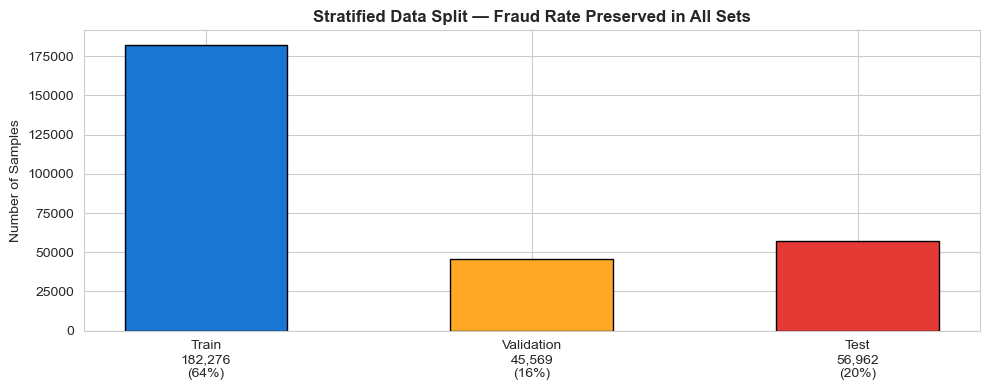


 Stratified split complete — fraud ratio preserved in all sets!


In [4]:
# CELL 4: STRATIFIED TRAIN/VAL/TEST SPLIT

print('=== Step 2: Stratified Train/Val/Test Split ===')

X = df_fe.drop('Class', axis=1)
y = df_fe['Class']

print(f'Feature matrix X: {X.shape}')
print(f'Target vector y:  {y.shape}')
print(f'Features: {list(X.columns)}')

# Step 1: 80% train+val, 20% test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y       # ← Critical: maintains fraud ratio in each split
)

# Step 2: 80% train, 20% val (from trainval)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.20,
    random_state=42,
    stratify=y_trainval
)

print('\n=== Split Summary ===')
for name, X_s, y_s in [('Train', X_train, y_train),
                        ('Validation', X_val, y_val),
                        ('Test', X_test, y_test)]:
    fraud_n = y_s.sum()
    print(f'  {name:12s}: {len(X_s):,} samples | '
          f'Fraud={fraud_n} ({y_s.mean()*100:.3f}%) | '
          f'Split={len(X_s)/len(X)*100:.1f}%')

# Visualize split
fig, ax = plt.subplots(figsize=(10, 4))
split_sizes = [len(X_train), len(X_val), len(X_test)]
split_labels = [f'Train\n{len(X_train):,}\n({len(X_train)/len(X)*100:.0f}%)',
                f'Validation\n{len(X_val):,}\n({len(X_val)/len(X)*100:.0f}%)',
                f'Test\n{len(X_test):,}\n({len(X_test)/len(X)*100:.0f}%)']
bars = ax.bar(split_labels, split_sizes,
              color=['#1976D2', '#FFA726', '#E53935'],
              edgecolor='black', width=0.5)
ax.set_title('Stratified Data Split — Fraud Rate Preserved in All Sets',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Samples')
plt.tight_layout()
plt.savefig('../results/data_split.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n Stratified split complete — fraud ratio preserved in all sets!')

=== Step 3: Feature Scaling ===
  IMPORTANT: Scaler fit ONLY on training data!
   Prevents data leakage from test/val into training.

Columns to scale: ['Amount', 'Log_Amount', 'Hour_sin', 'Hour_cos']
V1-V28: Already PCA-transformed → no additional scaling

=== Scaling Verification (Train set) ===
  Amount         : mean=-0.000000, std=1.000003 →  Correct
  Log_Amount     : mean=-0.000000, std=1.000003 →  Correct
  Hour_sin       : mean=+0.000000, std=1.000003 →  Correct
  Hour_cos       : mean=-0.000000, std=1.000003 →  Correct


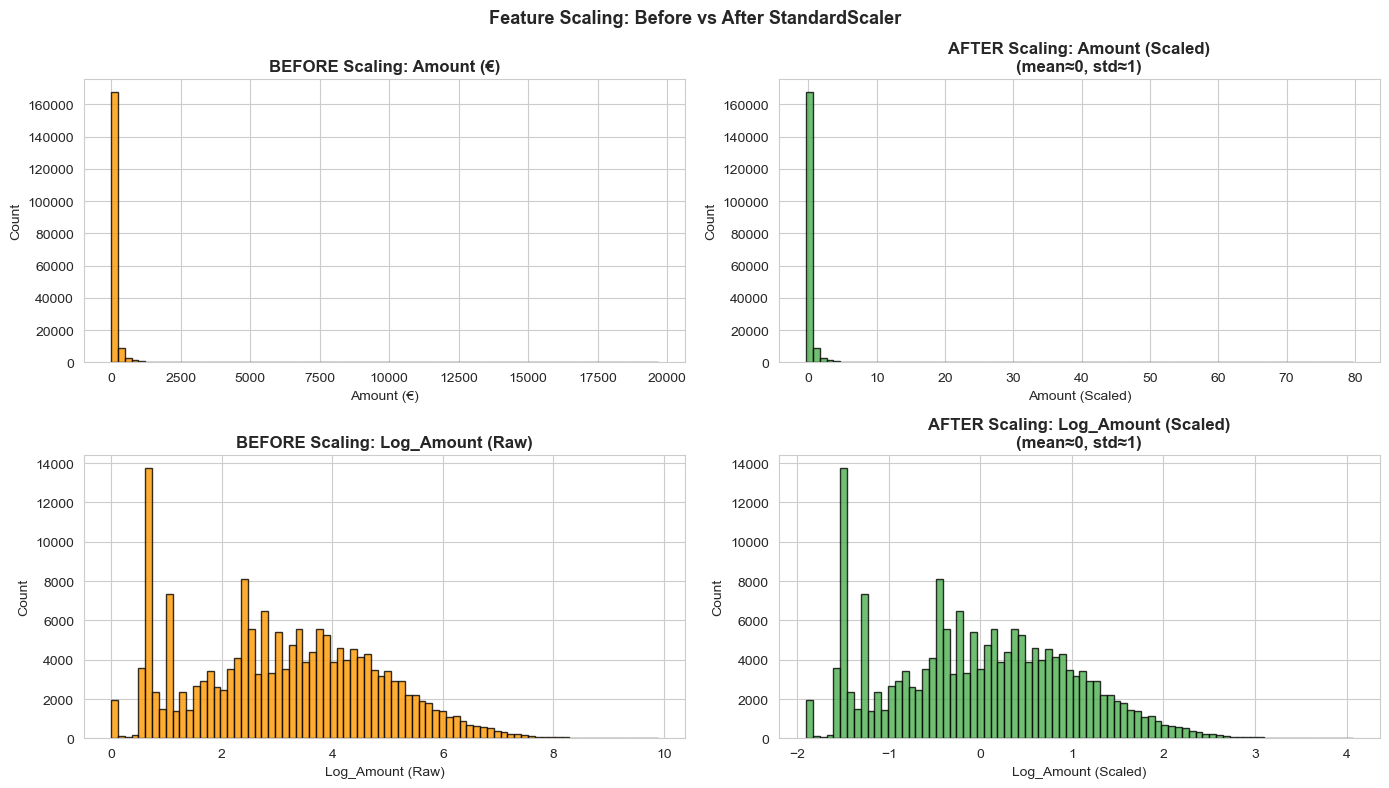


 Scaler saved to results/scaler.pkl (for deployment use)


In [5]:
# CELL 5: FEATURE SCALING

print('=== Step 3: Feature Scaling ===')
print('  IMPORTANT: Scaler fit ONLY on training data!')
print('   Prevents data leakage from test/val into training.\n')

# Only scale Amount and Log_Amount (V1-V28 are already PCA-scaled)
cols_to_scale = ['Amount', 'Log_Amount', 'Hour_sin', 'Hour_cos']
print(f'Columns to scale: {cols_to_scale}')
print(f'V1-V28: Already PCA-transformed → no additional scaling')

scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = X_train.copy()
X_val_scaled   = X_val.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_val_scaled[cols_to_scale]   = scaler.transform(X_val[cols_to_scale])
X_test_scaled[cols_to_scale]  = scaler.transform(X_test[cols_to_scale])

# Verify scaling
print('\n=== Scaling Verification (Train set) ===')
for col in cols_to_scale:
    mean = X_train_scaled[col].mean()
    std  = X_train_scaled[col].std()
    print(f'  {col:15s}: mean={mean:+.6f}, std={std:.6f} '
          f'→ {" Correct" if abs(mean) < 0.01 and abs(std-1) < 0.01 else "  Check"}')

# Before/After scaling visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
scale_pairs = [
    (X_train['Amount'], X_train_scaled['Amount'], 'Amount (€)', 'Amount (Scaled)'),
    (X_train['Log_Amount'], X_train_scaled['Log_Amount'], 'Log_Amount (Raw)', 'Log_Amount (Scaled)'),
]

for row, (before, after, label_b, label_a) in enumerate(scale_pairs):
    axes[row, 0].hist(before, bins=80, color='#FF9800', alpha=0.8, edgecolor='black')
    axes[row, 0].set_title(f'BEFORE Scaling: {label_b}', fontweight='bold')
    axes[row, 0].set_xlabel(label_b)
    axes[row, 0].set_ylabel('Count')

    axes[row, 1].hist(after, bins=80, color='#4CAF50', alpha=0.8, edgecolor='black')
    axes[row, 1].set_title(f'AFTER Scaling: {label_a}\n(mean≈0, std≈1)', fontweight='bold')
    axes[row, 1].set_xlabel(label_a)
    axes[row, 1].set_ylabel('Count')

plt.suptitle('Feature Scaling: Before vs After StandardScaler',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/scaling_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Save scaler for deployment
joblib.dump(scaler, '../results/scaler.pkl')
print('\n Scaler saved to results/scaler.pkl (for deployment use)')